# Machine Learning Basics II: The Regression Problem

files needed = ('ames.csv', 'laptop.csv')

In this notebook, we move away from classification (predicting a discrete outcome) to regression (predicting a continuous outcome). We will introduce the basic concepts by using OLS linear regression as a predictive tool.

Further, we will consider a situation in which the number of features $X$ is large relative to the number of observations $N$. In this context, prediction using a simple OLS regression that controls for all of the $X$ features might not work well. So we'll take on the issue of *model selection*.

One way to select our model is to use theory to guide selection of the appropriate $X$ variables. But if we don't have a proper theory, or if all we care about is prediction (not inference), then we might use a regularization method to select our model from a set of candidates.

We will consider some basic techniques: **LASSO and Ridge regressions**. Regularization methods like these are an important part of the ML programmer's toolkit.

## Predicting Housing Prices

Let's begin with a set of data with housing prices in Ames, Iowa from 2006 to 2010. This data set has detailed data on housing prices as well as many house features.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
import os
os.chdir('/Users/jackson/Documents/ECON570')

In [6]:
housing = pd.read_csv('data/ames.csv')
housing.set_index(keys='Id', inplace=True)
housing.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


The target column is `SalePrice` and the other columns are features. How many features are there?

In [7]:
housing.shape

(1460, 80)

Too many for `.pairplot()`! Let's check for columns with missing values.

In [8]:
null_vals = housing.isnull().sum()
null_vals[null_vals > 0]

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

Some of these features have a lot of missing values. Before we start training models, we need to deal with this issue.

Let's drop features with at least 500 missing values (about one-third) and fill in the rest of the missing values with zeros. This might not be the most delicate way to deal with missing values, but for now I think it is reasonable.

In [9]:
# Drop columns with >500 missing values 
drop_cols = null_vals[null_vals > 500].index.to_list()
housing.drop(columns=drop_cols, inplace=True)
# Fill in NaN values with zeros
housing = housing.fillna(0)
# Take the log of SalePrice
housing['logSalePrice']=np.log(housing['SalePrice'])
housing.drop(columns='SalePrice', inplace=True)
housing.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,logSalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2008,WD,Normal,12.247694
2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,5,2007,WD,Normal,12.109011
3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,9,2008,WD,Normal,12.317167
4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,272,0,0,0,0,2,2006,WD,Abnorml,11.849398
5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,12,2008,WD,Normal,12.429216


## First Pass: OLS Regression

The data looks to be in relatively good shape now. Let's start our prediction by trying to estimate an OLS regression of the log of the sale price on every housing feature available. So, let's build the formula from the data.

This time, let's use `LinearRegression` to estimate the OLS model.

Note the differences with `sklearn`:
- No `.summary()` available like with the `smf.ols` we've used. This is not a big deal because we are not really interested in the coefficients themselves. We're doing prediction, not inference!
- `LinearRegression` doesn't automatically categorize the non-numeric variables like statsmodels did. Pandas `.get_dummies()` will do that for us.

In [10]:
X = housing.drop(columns='logSalePrice')
X = pd.get_dummies(X)
y = housing['logSalePrice']

res_ols = LinearRegression().fit(X,y)
y_pred_ols = res_ols.predict(X)
print(pd.DataFrame(y_pred_ols,y))

                      0
logSalePrice           
12.247694     12.234324
12.109011     12.205883
12.317167     12.263002
11.849398     12.000702
12.429216     12.564133
...                 ...
12.072541     12.103830
12.254863     12.246452
12.493130     12.552780
11.864462     11.872347
11.901583     11.879667

[1460 rows x 1 columns]


The predicted values from the model are not far off from the true `logSalePrice` values.

For our classification problems, we used `score` and `confusion_matrix` to evaluate how well our model predicted in-sample. With a continuous target variable like `logSalePrice`, we'll need to use another objective. A commonly used measure is the **Root Mean Squared Error (RMSE)**: $$\sqrt{ \frac{1}{N} \sum_{i=1}^N (y_i-\hat y_i)^2}$$

In [11]:
rmse_ols = root_mean_squared_error(y, y_pred_ols)
print("The RMSE from OLS in-sample prediction is", rmse_ols)

The RMSE from OLS in-sample prediction is 0.09557651734288142


Does the model predict well? The RMSE gives us a snapshot of the prediction performance. Lower RMSE can be interpreted as increased predictive performance.

It is worth noting that our objective might differ depending on the nature of the problem. Consider the following scenarios:
- We don't care if a few predictions are way off as long as the rest of them are pretty good. Predicting outliers is not important.
- Large prediction errors are catastrophic. Predicting outliers is important.

Naturally, different evaluation methods might be appropriate for these two scenarios.

## Testing and Training Sets

As we did in the classification problem, let's hold out some data for testing. For now, let's split the data 80/20 between training and testing.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

Let's refit the model only on the training dataset.

In [13]:
res_ols = LinearRegression().fit(X_train,y_train)

And test the prediction out-of-sample on the test set.

In [14]:
y_pred_ols = res_ols.predict(X_test)
print(pd.DataFrame(y_pred_ols,y_test))

                      0
logSalePrice           
11.947949     11.941941
12.691580     12.743680
11.652687     11.500344
11.976659     12.021284
12.661914     12.652989
...                 ...
11.401670     11.871702
12.468437     12.472443
12.149502     12.129472
11.589887     11.701443
11.732061     11.695351

[292 rows x 1 columns]


Evaluate again using the RMSE.

In [15]:
rmse_ols = root_mean_squared_error(y_test, y_pred_ols)
print("The RMSE from OLS out-of-sample prediction is", rmse_ols)

The RMSE from OLS out-of-sample prediction is 0.12955190170222347


This RMSE is higher than the original for two reasons. First, the training set sample size is 80% of the size of the full sample. Further, and perhaps more importantly here, the test set data points were not used to train the model, so they do not influence the parameters that are used to evaluate the model's fit. This highlights the problem of *overfitting*, which we take on below.

## Practice

The file 'laptop.csv' contains information on a variety of laptops. Our goal is to build a model that predicts a laptop's price given its other features.

1. How many features are there?
2. Confirm that there are no missing values in the data.

3. Split columns into `Xprac` (features) and `yprac` (target). Use `pd.get_dummies()` to create dummies for each categorical variable in `Xprac`.
4. Use `train_test_split()` to split the data 80/20 training/testing.

5. Estimate a `LinearRegression` on the training data.
6. Compute predicted values and the RMSE for the testing data.

In [23]:
laptop = pd.read_csv('data/laptop.csv')
laptop.head()

,Company,Type,OpSys,CPU,GPU,Ram,Weight,Touchscreen,ClockSpeed,HDD,SSD,PPI,Price
0,Apple,Ultrabook,Mac,Intel,Intel,8,1.37,0,2.3,0.0,0.128,312.781955,71378.6832
1,Apple,Ultrabook,Mac,Intel,Intel,8,1.34,0,1.8,0.0,0.000,175.939850,47895.5232
2,HP,Notebook,No,Intel,Intel,8,1.86,0,2.5,0.0,0.256,192.307692,30636.0000
3,Apple,Ultrabook,Mac,Intel,AMD,16,1.83,0,2.7,0.0,0.512,303.896104,135195.3360
4,Apple,Ultrabook,Mac,Intel,Intel,8,1.37,0,3.1,0.0,0.256,312.781955,96095.8080


In [25]:
Xprac = laptop.drop('Price', axis=1)
yprac = laptop['Price']
Xprac = pd.get_dummies(Xprac)
Xprac.shape

(1300, 33)

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    Xprac, yprac, test_size=0.2, random_state=42)

In [28]:
resprac_ols = LinearRegression().fit(X_train,y_train)
yprac_pred_ols = resprac_ols.predict(X_test)
print(pd.DataFrame(yprac_pred_ols,y_test))
rmse_ols = root_mean_squared_error(y_test, yprac_pred_ols)
print("The RMSE from OLS out-of-sample prediction is", rmse_ols)

                         0
Price                     
89084.1600    60697.295979
79866.7200    72094.084842
24988.3200    32335.020175
22324.3200    18897.889544
99900.0000    57292.686093
...                    ...
55571.0400    67301.588542
98301.6000   125955.729027
153705.3408  140441.631927
52054.5600    68320.755607
31168.8000    23656.768168

[260 rows x 1 columns]
The RMSE from OLS out-of-sample prediction is 17492.779849122202


In [29]:
yprac.describe()

count      1300.000000
mean      59945.621040
std       37251.107894
min        9270.720000
25%       31914.720000
50%       52161.120000
75%       79346.840400
max      324954.720000
Name: Price, dtype: float64

## Model Selection

In principle, we could add even more controls to the OLS (squared, cubed, interaction terms...) but there is a chance that the model won't do much better when it comes to predicting the out-of-sample fit. This brings us to the most fundamental tradeoff in machine learning models: the *bias-variance tradeoff*.  [Here](http://scott.fortmann-roe.com/docs/BiasVariance.html) is a nice overview with some helpful visualizations.

In order to prevent overfitting of the model, we'll consider two kinds of penalized least squares regressions: Ridge and LASSO. Remember that the OLS regression solves $$\min_{\beta} (Y-X\beta)^T(Y-X\beta)$$

A penalized least squares regression instead solves $$\min_{\beta} (Y-X\beta)^T(Y-X\beta)+\alpha f(\beta)$$ where $\alpha$ is a tuning parameter and $f(\beta)$ is a penalty (or regularization) term.

Ridge and LASSO differ in their penalty terms, but they essentially do the same thing $-$ shrink the parameter estimates relative to OLS. These models intentionally introduce some bias to the model, with the goal of reducing the variance. Our objective is to minimize the out-of-sample RSME fit by properly trading off between these two.

## Ridge Regression

The Ridge regression solves the penalized least squares model with $f(\beta)=\sum_{i=1}^p \beta_i^2$

We'll estimate on the training dataset, choosing the tuning parameter $\alpha$ that optimally trades off between bias and variance.

In [16]:
# Set the Ridge tuning parameter
alpha_ridge = 0.32
# Estimate the Ridge regression
res_ridge = Ridge(alpha = alpha_ridge).fit(X_train,y_train)
# Calculate predicted values
y_pred_ridge = res_ridge.predict(X_test)
# Calculate the RMSE
rmse_ridge = root_mean_squared_error(y_test, y_pred_ridge)
print("The RMSE from Ridge prediction on the test set is", rmse_ridge)

The RMSE from Ridge prediction on the test set is 0.1263852402581464


This lower RMSE on the test data relative to the OLS model suggests an improvement in predictive performance.

Why do we see an improvement? It is informative to see how the coefficient estimates depend on $\alpha$.

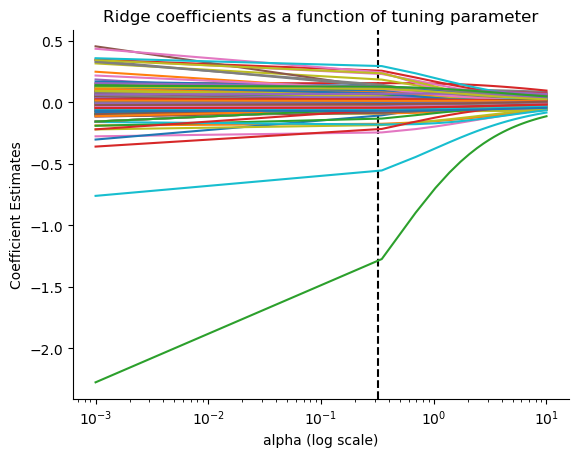

In [17]:
alphas = np.linspace(0.001,10,30)
ridge = Ridge(max_iter = 100000)
coefs = []
rmse_is = []
rmse_os = []

for a in alphas:
    ridge.set_params(alpha=a)
    ridge.fit(X_train, y_train)
    coefs.append(ridge.coef_)
    y_is = ridge.predict(X_train)
    rmse_is.append(root_mean_squared_error(y_train, y_is))
    y_os = ridge.predict(X_test)
    rmse_os.append(root_mean_squared_error(y_test, y_os))

ax = plt.gca()

plt.axvline(x=alpha_ridge, color='black', linestyle='--')
sns.despine(ax=ax)

ax.plot(alphas, coefs)
ax.set_xscale('log')
plt.axis('tight')
plt.xlabel('alpha (log scale)')
plt.ylabel('Coefficient Estimates')
plt.title('Ridge coefficients as a function of tuning parameter');

As $\alpha$ is increased, all of the parameter estimates shrink toward zero.

- $\alpha=0$ represents the OLS case, which overfits in this case.
- If $\alpha$ is large, then all the coefficients are essentially zero. Extreme underfitting.
- The optimal $\alpha$ is somewhere in between these two.

So, how do in-sample and out-of-sample fit depend on $\alpha$?

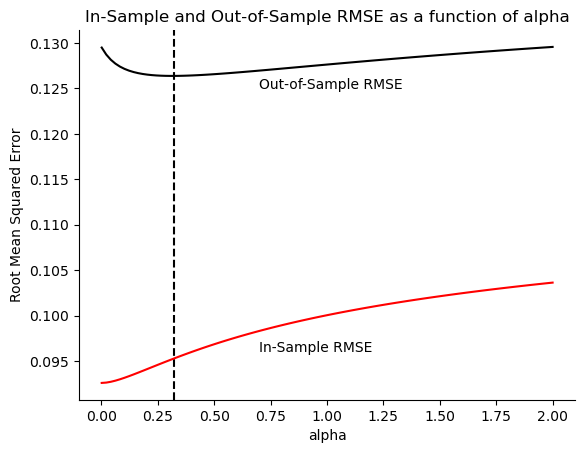

In [18]:
alphas = np.linspace(0.001,2,100)
ridge = Ridge(max_iter = 100000)
rmse_is = []
rmse_os = []

for a in alphas:
    ridge.set_params(alpha=a)
    ridge.fit(X_train, y_train)
    y_is = ridge.predict(X_train)
    rmse_is.append(root_mean_squared_error(y_train, y_is))
    y_os = ridge.predict(X_test)
    rmse_os.append(root_mean_squared_error(y_test, y_os))

ax = plt.gca()

plt.axvline(x=alpha_ridge, color='black', linestyle='--')

ax.plot(alphas, rmse_os, color='black')
ax.plot(alphas, rmse_is, color='red')
sns.despine(ax=ax)

ax.text(.7, .125, 'Out-of-Sample RMSE')
ax.text(.7, .096, 'In-Sample RMSE')
plt.axis('tight')
plt.xlabel('alpha')
plt.ylabel('Root Mean Squared Error')
plt.title('In-Sample and Out-of-Sample RMSE as a function of alpha');

Looks like our choice of $\alpha=0.32$ minimizes the out-of-sample fit. Let's see if we can do even better with another type of regularization.

## LASSO Regression

The LASSO regression solves the penalized least squares model with $f(\beta)=\sum_{i=1}^p | \beta_i | $

We'll estimate on the training dataset, choosing yet another tuning parameter $\alpha$ that trades off between bias and variance.

In [19]:
# Set the lasso tuning parameter
alpha_lasso = .00017
# Estimate the LASSO regression
res_lasso = Lasso(alpha = alpha_lasso, max_iter = 100000).fit(X_train,y_train)
# Calculate predicted values
y_pred_lasso = res_lasso.predict(X_test)
# Calculate the RMSE
rmse_lasso = root_mean_squared_error(y_test, y_pred_lasso)
print("The RMSE from Lasso prediction on the test set is", rmse_lasso)

The RMSE from Lasso prediction on the test set is 0.1223488691822492


Looks like LASSO does even better than Ridge in this context.

What happens to the coefficients as we change the tuning parameter $\alpha$?

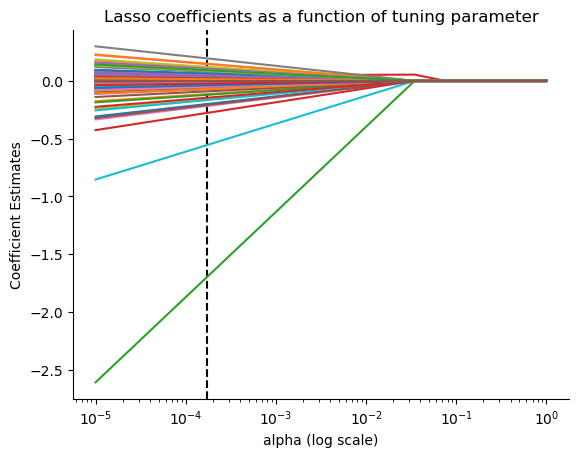

In [20]:
alphas = np.linspace(0.00001,1,30)
lasso = Lasso(max_iter = 100000)
coefs = []

for a in alphas:
    lasso.set_params(alpha=a)
    lasso.fit(X_train, y_train)
    coefs.append(lasso.coef_)

ax = plt.gca()

plt.axvline(x=alpha_lasso, color='black', linestyle='--')
sns.despine()


ax.plot(alphas, coefs)
ax.set_xscale('log')
plt.axis('tight')
plt.xlabel('alpha (log scale)')
plt.ylabel('Coefficient Estimates')
plt.title('Lasso coefficients as a function of tuning parameter');

They seem to shrink toward zero in a different way, features dropping out one by one as $\alpha$ increases. Eventually, they are all zero.

What happens to the in-sample and out-of-sample fit when we change $\alpha$?

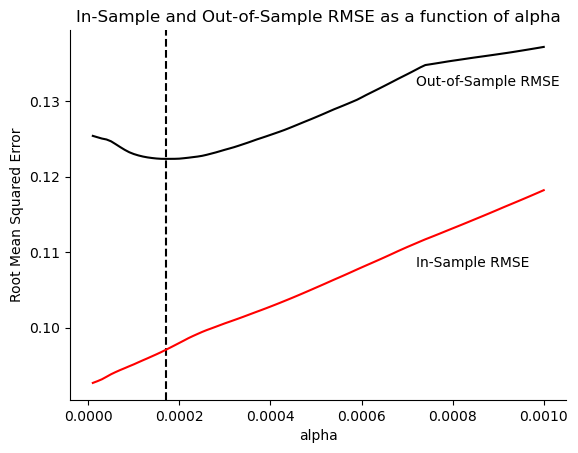

In [21]:
alphas = np.linspace(0.00001,.001,100)
lasso = Lasso(max_iter = 100000)
rmse_is = []
rmse_os = []

for a in alphas:
    lasso.set_params(alpha=a)
    lasso.fit(X_train, y_train)
    y_is = lasso.predict(X_train)
    rmse_is.append(root_mean_squared_error(y_train, y_is))
    y_os = lasso.predict(X_test)
    rmse_os.append(root_mean_squared_error(y_test, y_os))

ax = plt.gca()

plt.axvline(x=alpha_lasso, color='black', linestyle='--')

ax.plot(alphas, rmse_os, color='black')
ax.plot(alphas, rmse_is, color='red')
sns.despine(ax=ax)

ax.text(.00072, .132, 'Out-of-Sample RMSE')
ax.text(.00072, .108, 'In-Sample RMSE')
plt.axis('tight')
plt.xlabel('alpha')
plt.ylabel('Root Mean Squared Error')
plt.title('In-Sample and Out-of-Sample RMSE as a function of alpha');

The right choice of $\alpha$ leads to superior performance of LASSO in this context.

## Cross-Validation

I manually picked the $\alpha$'s for each model to minimize out-of-sample fit. In practice, we typically use *cross-validation* to pick model parameters like $\alpha$ that are not estimated. In this context, `sklearn` has `RidgeCV` and `LassoCV` that select the tuning parameter $\alpha$ for Ridge, LASSO using cross-validation.

## More Practice

Return to the laptop data from the original practice with the 80/20 training/testing split.

1. Fit the training data with a Ridge regression using $\alpha=1.0$ as an initial parameter. Does the RMSE for the testing data improve on the OLS model?
2. Repeat 1. with a LASSO regression.
3. Experiment with different values of $\alpha>0$. Can you beat the OLS RMSE on the testing data with either Ridge or LASSO?